# Análisis exploratorio de las tablas EAL (2022–2024)

## Contexto y método

### Objetivo

Realizar un análisis exploratorio (*EDA*) sencillo sobre las tablas EAL disponibles para:

- conocer la estructura y cobertura de los datos;
- revisar ausencias, duplicados y rangos inválidos;
- calcular media, mediana, moda, desviación estándar y cuartiles;
- visualizar distribuciones y comparaciones;
- señalar posibles valores anómalos mediante la regla del rango intercuartílico (IQR);

### Supuestos clave

- Los valores son porcentajes y, por tanto, deben estar entre 0 y 100.
- En EAL-16, las categorías `NADA`, `POCO`, `BASTANTE` y `MUCHO` deben sumar aproximadamente 100 por fila; la columna `TOTAL` es estructural.
- En EAL-21 una empresa puede seleccionar varias competencias, por lo que los porcentajes **no tienen por qué sumar 100**.


## Carga librerias

In [42]:
from pathlib import Path
import re
import sys
import warnings

import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

In [43]:

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
AZUL = "#2F6B9A"
NARANJA = "#D9822B"
GRIS = "#5B6573"

In [ ]:
directorio_actual = Path.cwd().resolve()
raiz_proyecto = directorio_actual.parent

RUTA_DATOS_RELATIVA = Path("Data") / "Encuesta_EAL" / "Raw_2022-2024"

ARCHIVOS_POR_ANIO = {
    2022: "Tablas_EAL_2022.xlsx",
    2023: "Tablas_EAL_2023.xlsx",
    2024: "Tablas_EAL_2024.xlsx",
}

HOJAS_ANALISIS = ["EAL-16", "EAL-21"]

directorio_datos = raiz_proyecto / RUTA_DATOS_RELATIVA
archivos_por_anio = {
    anio: directorio_datos / nombre
    for anio, nombre in ARCHIVOS_POR_ANIO.items()
}
archivos = [archivos_por_anio[anio] for anio in sorted(archivos_por_anio)]


print(f"Raíz del proyecto: {raiz_proyecto}")
print(f"Carpeta de datos: {directorio_datos}")
print(f"Archivos configurados: {len(archivos)}")
for anio, archivo in archivos_por_anio.items():
    print(f" - {anio}: {archivo.name}")
print("Hojas seleccionadas:", ", ".join(HOJAS_ANALISIS))

Raíz del proyecto: C:\Users\raulm\Desktop\Simulator\ProjecteData\Equip_33
Carpeta de datos: C:\Users\raulm\Desktop\Simulator\ProjecteData\Equip_33\Data\Encuesta_EAL\Raw_2022-2024
Archivos configurados: 3
 - 2022: Tablas_EAL_2022.xlsx
 - 2023: Tablas_EAL_2023.xlsx
 - 2024: Tablas_EAL_2024.xlsx
Hojas seleccionadas: EAL-16, EAL-21


### 2. Inventario de libros y hojas

**Propósito.** Confirmar qué años, hojas y dimensiones están disponibles antes de combinar datos.

**Método.** Se abre cada libro sin modificarlo y se registra el número de filas y columnas de cada hoja.

In [45]:
inventario = []

for anio, archivo in archivos_por_anio.items():
    libro = pd.ExcelFile(archivo)
    hojas_ausentes = sorted(set(HOJAS_ANALISIS) - set(libro.sheet_names))
    if hojas_ausentes:
        raise ValueError(f"{archivo.name} no contiene las hojas: {hojas_ausentes}")
    for hoja in HOJAS_ANALISIS:
        tabla_cruda = pd.read_excel(archivo, sheet_name=hoja, header=None)
        inventario.append({
            "archivo": archivo.name,
            "anio": anio,
            "hoja": hoja,
            "filas_crudas": tabla_cruda.shape[0],
            "columnas_crudas": tabla_cruda.shape[1],
        })

df_inventario = pd.DataFrame(inventario)
display(df_inventario)

,archivo,anio,hoja,filas_crudas,columnas_crudas
0,Tablas_EAL_2022.xlsx,2022,EAL-16,125,6
1,Tablas_EAL_2022.xlsx,2022,EAL-21,21,5
2,Tablas_EAL_2023.xlsx,2023,EAL-16,125,6
3,Tablas_EAL_2023.xlsx,2023,EAL-21,21,5
4,Tablas_EAL_2024.xlsx,2024,EAL-16,125,6
5,Tablas_EAL_2024.xlsx,2024,EAL-21,21,5


### 3. Normalización de los bloques

**Propósito.** Convertir las cabeceras repetidas y los distintos bloques de Excel en una sola tabla analítica.

**Método.** Cada fila que contiene `TOTAL` identifica una cabecera. Se conserva el título del bloque anterior, se leen las filas numéricas siguientes y se generan registros con una observación por combinación de año, bloque, indicador y categoría.

In [46]:
def texto_limpio(valor):
    '''Devuelve texto sin espacios repetidos; mantiene vacío si no hay contenido.'''
    if pd.isna(valor):
        return ""
    return re.sub(r"\s+", " ", str(valor)).strip()


def extraer_bloques(archivo, hoja):
    '''Extrae los bloques tabulares de una hoja EAL y devuelve registros en formato largo.'''
    tabla = pd.read_excel(archivo, sheet_name=hoja, header=None)
    anio = int(re.search(r"(20\d{2})", archivo.stem).group(1))
    registros = []

    filas_cabecera = []
    for indice, fila in tabla.iterrows():
        valores = [texto_limpio(v).upper() for v in fila.tolist()]
        if "TOTAL" in valores:
            filas_cabecera.append(indice)

    for posicion, fila_cabecera in enumerate(filas_cabecera):
        fin_bloque = filas_cabecera[posicion + 1] if posicion + 1 < len(filas_cabecera) else len(tabla)

        # El título es la línea EAL más cercana situada antes de la cabecera.
        titulo = ""
        for fila_previa in range(fila_cabecera - 1, -1, -1):
            candidato = texto_limpio(tabla.iloc[fila_previa, 0])
            if re.match(r"^EAL-", candidato, flags=re.IGNORECASE):
                titulo = candidato
                break

        codigo = re.match(r"^(EAL-\d+[a-z]?)", titulo, flags=re.IGNORECASE)
        bloque = codigo.group(1).upper() if codigo else hoja
        universo = re.sub(r"^EAL-\d+[a-z]?\.\s*", "", titulo, flags=re.IGNORECASE)

        categorias = [texto_limpio(v).upper() for v in tabla.iloc[fila_cabecera, 1:].tolist()]

        for fila_datos in range(fila_cabecera + 1, fin_bloque):
            indicador = texto_limpio(tabla.iloc[fila_datos, 0])
            if not indicador or indicador.startswith("(") or re.match(r"^EAL-", indicador, flags=re.IGNORECASE):
                continue

            valores_numericos = pd.to_numeric(tabla.iloc[fila_datos, 1:], errors="coerce")
            if valores_numericos.notna().sum() == 0:
                continue

            for categoria, valor in zip(categorias, valores_numericos):
                if categoria and pd.notna(valor):
                    registros.append({
                        "archivo": archivo.name,
                        "anio": anio,
                        "hoja": hoja,
                        "bloque": bloque,
                        "universo": universo,
                        "indicador": indicador,
                        "categoria": categoria,
                        "valor": float(valor),
                    })

    return registros


registros = []
for archivo in archivos:
    for hoja in HOJAS_ANALISIS:
        registros.extend(extraer_bloques(archivo, hoja))

df = pd.DataFrame(registros).sort_values(
    ["anio", "hoja", "bloque", "indicador", "categoria"]
).reset_index(drop=True)

# TOTAL=100 es una constante estructural en EAL-16; se conserva para validación,
# pero se excluye de las distribuciones y medidas descriptivas.
df["es_total_estructural"] = (df["hoja"] == "EAL-16") & (df["categoria"] == "TOTAL")
df_analisis = df.loc[~df["es_total_estructural"]].copy()

print(f"Registros normalizados: {len(df):,}")
print(f"Registros usados en análisis descriptivo: {len(df_analisis):,}")
display(df.head(10))

Registros normalizados: 1,182
Registros usados en análisis descriptivo: 972


,archivo,anio,hoja,bloque,universo,indicador,categoria,valor,es_total_estructural
0,Tablas_EAL_2022.xlsx,2022,EAL-16,EAL-16,"EMPRESAS, SEGÚN GRADO DE IMPORTANCIA PARA EL DESARROLLO DE LA EMPRESA EN LOS PRÓXIMOS ...",Administrativas de oficina,BASTANTE,43.71,False
1,Tablas_EAL_2022.xlsx,2022,EAL-16,EAL-16,"EMPRESAS, SEGÚN GRADO DE IMPORTANCIA PARA EL DESARROLLO DE LA EMPRESA EN LOS PRÓXIMOS ...",Administrativas de oficina,MUCHO,23.88,False
2,Tablas_EAL_2022.xlsx,2022,EAL-16,EAL-16,"EMPRESAS, SEGÚN GRADO DE IMPORTANCIA PARA EL DESARROLLO DE LA EMPRESA EN LOS PRÓXIMOS ...",Administrativas de oficina,NADA,7.90,False
3,Tablas_EAL_2022.xlsx,2022,EAL-16,EAL-16,"EMPRESAS, SEGÚN GRADO DE IMPORTANCIA PARA EL DESARROLLO DE LA EMPRESA EN LOS PRÓXIMOS ...",Administrativas de oficina,POCO,24.51,False
4,Tablas_EAL_2022.xlsx,2022,EAL-16,EAL-16,"EMPRESAS, SEGÚN GRADO DE IMPORTANCIA PARA EL DESARROLLO DE LA EMPRESA EN LOS PRÓXIMOS ...",Administrativas de oficina,TOTAL,100.00,True
5,Tablas_EAL_2022.xlsx,2022,EAL-16,EAL-16,"EMPRESAS, SEGÚN GRADO DE IMPORTANCIA PARA EL DESARROLLO DE LA EMPRESA EN LOS PRÓXIMOS ...",Básicas de cálculo y/o comunicación oral o escrita,BASTANTE,33.56,False
6,Tablas_EAL_2022.xlsx,2022,EAL-16,EAL-16,"EMPRESAS, SEGÚN GRADO DE IMPORTANCIA PARA EL DESARROLLO DE LA EMPRESA EN LOS PRÓXIMOS ...",Básicas de cálculo y/o comunicación oral o escrita,MUCHO,10.26,False
7,Tablas_EAL_2022.xlsx,2022,EAL-16,EAL-16,"EMPRESAS, SEGÚN GRADO DE IMPORTANCIA PARA EL DESARROLLO DE LA EMPRESA EN LOS PRÓXIMOS ...",Básicas de cálculo y/o comunicación oral o escrita,NADA,17.60,False
8,Tablas_EAL_2022.xlsx,2022,EAL-16,EAL-16,"EMPRESAS, SEGÚN GRADO DE IMPORTANCIA PARA EL DESARROLLO DE LA EMPRESA EN LOS PRÓXIMOS ...",Básicas de cálculo y/o comunicación oral o escrita,POCO,38.58,False
9,Tablas_EAL_2022.xlsx,2022,EAL-16,EAL-16,"EMPRESAS, SEGÚN GRADO DE IMPORTANCIA PARA EL DESARROLLO DE LA EMPRESA EN LOS PRÓXIMOS ...",Básicas de cálculo y/o comunicación oral o escrita,TOTAL,100.00,True


## Resultados

### 4. Calidad y cobertura

**Propósito.** Verificar que la tabla normalizada es utilizable antes de calcular estadísticas.

**Método.** Se revisan cobertura por año/hoja, ausencias, duplicados de la clave lógica, porcentajes fuera de rango y sumas de EAL-16.

In [47]:
cobertura = (
    df.groupby(["anio", "hoja"])
      .agg(registros=("valor", "size"), bloques=("bloque", "nunique"), indicadores=("indicador", "nunique"))
      .reset_index()
)
display(cobertura)

faltantes = df.isna().sum().rename("valores_ausentes").to_frame()
faltantes["porcentaje"] = 100 * faltantes["valores_ausentes"] / len(df)
display(faltantes)

clave = ["anio", "hoja", "bloque", "indicador", "categoria"]
duplicados = int(df.duplicated(clave).sum())
fuera_rango = int((~df["valor"].between(0, 100)).sum())

sumas_eal16 = (
    df_analisis.query("hoja == 'EAL-16'")
      .groupby(["anio", "bloque", "indicador"])["valor"]
      .sum()
)
desviacion_suma = (sumas_eal16 - 100).abs()

print(f"Duplicados según la clave lógica: {duplicados}")
print(f"Valores fuera del rango 0–100: {fuera_rango}")
print(f"Máxima diferencia respecto a 100 en las sumas EAL-16: {desviacion_suma.max():.4f} puntos")

,anio,hoja,registros,bloques,indicadores
0,2022,EAL-16,350,7,10
1,2022,EAL-21,44,1,11
2,2023,EAL-16,350,7,10
3,2023,EAL-21,44,1,11
4,2024,EAL-16,350,7,10
5,2024,EAL-21,44,1,11


,valores_ausentes,porcentaje
archivo,0,0.00
anio,0,0.00
hoja,0,0.00
bloque,0,0.00
universo,0,0.00
indicador,0,0.00
categoria,0,0.00
valor,0,0.00
es_total_estructural,0,0.00


Duplicados según la clave lógica: 0
Valores fuera del rango 0–100: 0
Máxima diferencia respecto a 100 en las sumas EAL-16: 0.0010 puntos


### 5. Estadísticos descriptivos

**Propósito.** Resumir posición y dispersión de los porcentajes por hoja y categoría.

**Método.** Se calculan número de observaciones, media, mediana, moda informativa, desviación estándar, cuartiles, mínimo y máximo. La moda se deja vacía cuando todos los valores son únicos, porque en datos continuos no sería representativa.

In [48]:
def moda_informativa(serie):
    frecuencias = serie.value_counts(dropna=True)
    if frecuencias.empty or frecuencias.iloc[0] == 1:
        return np.nan
    return frecuencias.index[0]


estadisticos = (
    df_analisis.groupby(["hoja", "categoria"])["valor"]
      .agg(
          n="count",
          media="mean",
          mediana="median",
          moda=moda_informativa,
          desviacion="std",
          minimo="min",
          q1=lambda s: s.quantile(0.25),
          q3=lambda s: s.quantile(0.75),
          maximo="max",
      )
      .reset_index()
)
display(estadisticos.round(2))

,hoja,categoria,n,media,mediana,moda,desviacion,minimo,q1,q3,maximo
0,EAL-16,BASTANTE,210,40.22,41.60,40.67,8.10,13.17,36.10,46.20,53.96
1,EAL-16,MUCHO,210,26.86,27.18,9.54,12.63,3.50,16.29,36.97,56.33
2,EAL-16,NADA,210,9.64,7.88,6.77,7.60,0.35,3.70,14.23,37.18
3,EAL-16,POCO,210,23.28,21.28,NaN,11.74,2.65,13.89,33.16,50.38
4,EAL-21,CONSTRUCCIÓN,33,14.20,10.66,NaN,17.16,0.55,2.86,15.70,66.29
5,EAL-21,INDUSTRIA,33,15.90,11.38,NaN,15.60,0.75,9.11,19.03,64.15
6,EAL-21,SERVICIOS,33,16.94,13.87,NaN,10.58,1.27,10.16,27.23,44.99
7,EAL-21,TOTAL,33,16.40,13.53,NaN,11.51,1.25,8.89,21.55,50.84


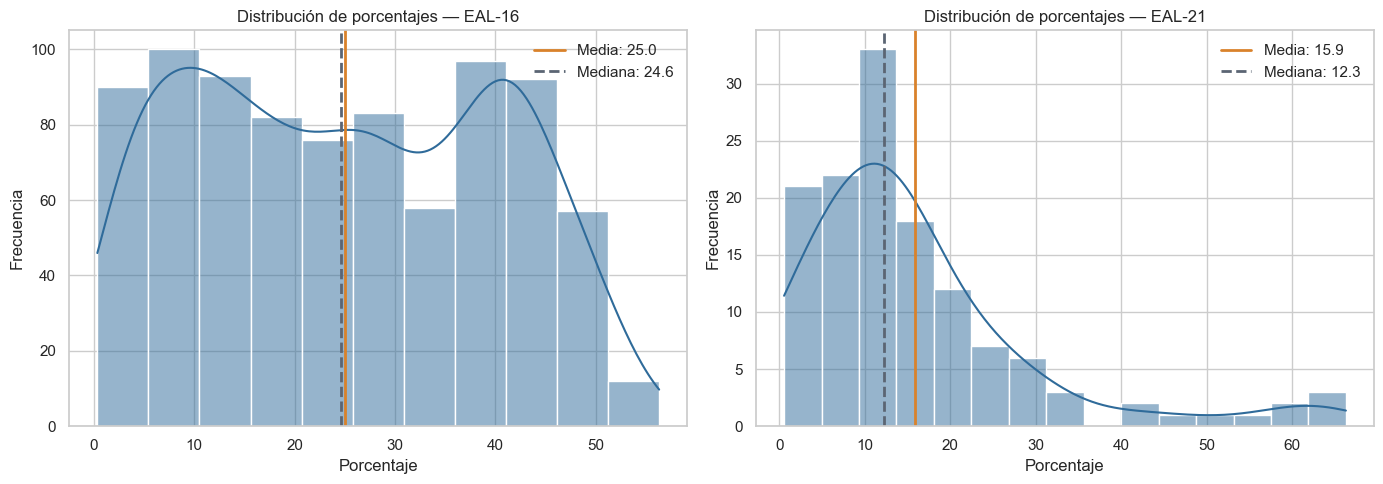

In [49]:
hojas = sorted(df_analisis["hoja"].unique())
fig, ejes = plt.subplots(1, len(hojas), figsize=(14, 5), squeeze=False)

for ax, hoja in zip(ejes.flat, hojas):
    valores = df_analisis.loc[df_analisis["hoja"] == hoja, "valor"]
    sns.histplot(valores, bins="auto", kde=True, color=AZUL, edgecolor="white", ax=ax)
    ax.axvline(valores.mean(), color=NARANJA, linewidth=2, label=f"Media: {valores.mean():.1f}")
    ax.axvline(valores.median(), color=GRIS, linestyle="--", linewidth=2, label=f"Mediana: {valores.median():.1f}")
    ax.set(title=f"Distribución de porcentajes — {hoja}", xlabel="Porcentaje", ylabel="Frecuencia")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

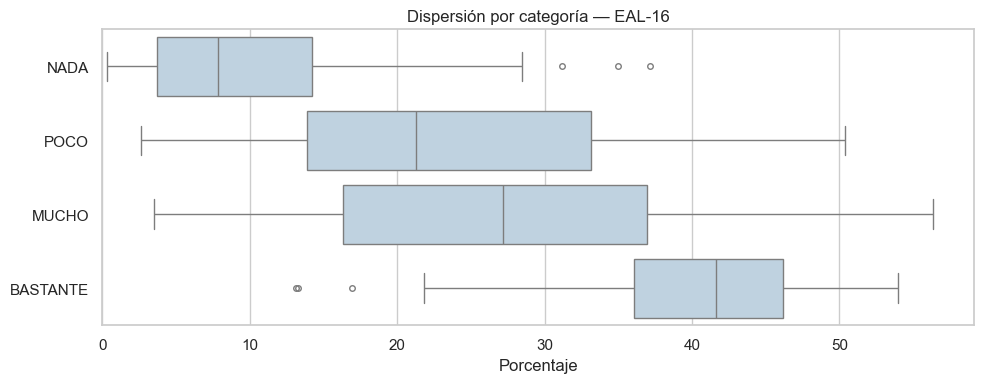

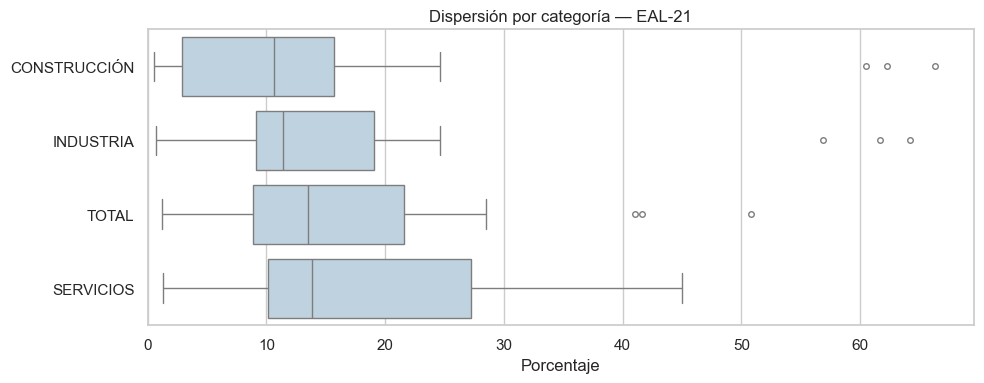

In [50]:
for hoja in hojas:
    datos_hoja = df_analisis[df_analisis["hoja"] == hoja]
    orden = datos_hoja.groupby("categoria")["valor"].median().sort_values().index
    fig, ax = plt.subplots(figsize=(10, max(4, 0.6 * len(orden))))
    sns.boxplot(
        data=datos_hoja,
        y="categoria",
        x="valor",
        order=orden,
        color="#B9D3E6",
        fliersize=4,
        ax=ax,
    )
    ax.set(title=f"Dispersión por categoría — {hoja}", xlabel="Porcentaje", ylabel="")
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()

### 6. Posibles valores anómalos

**Propósito.** Identificar observaciones alejadas de la distribución de su categoría.

**Método.** Dentro de cada combinación hoja–categoría se calculan Q1, Q3 e IQR. Se marca como posible anomalía un valor inferior a `Q1 − 1,5×IQR` o superior a `Q3 + 1,5×IQR`. Esta regla es descriptiva: un valor extremo puede ser correcto y relevante.

In [51]:
cuartiles = (
    df_analisis.groupby(["hoja", "categoria"])["valor"]
      .agg(q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
      .reset_index()
)
cuartiles["iqr"] = cuartiles["q3"] - cuartiles["q1"]
cuartiles["limite_inferior_iqr"] = cuartiles["q1"] - 1.5 * cuartiles["iqr"]
cuartiles["limite_superior_iqr"] = cuartiles["q3"] + 1.5 * cuartiles["iqr"]

df_anomalias = df_analisis.merge(
    cuartiles[["hoja", "categoria", "limite_inferior_iqr", "limite_superior_iqr"]],
    on=["hoja", "categoria"],
    how="left",
)
df_anomalias["posible_anomalia"] = ~df_anomalias["valor"].between(
    df_anomalias["limite_inferior_iqr"], df_anomalias["limite_superior_iqr"]
)

resumen_anomalias = (
    df_anomalias.groupby(["hoja", "categoria"])
      .agg(observaciones=("valor", "size"), anomalias=("posible_anomalia", "sum"))
      .reset_index()
)
resumen_anomalias["porcentaje_anomalias"] = 100 * resumen_anomalias["anomalias"] / resumen_anomalias["observaciones"]
display(resumen_anomalias.round(2))

columnas_revision = [
    "anio", "hoja", "bloque", "indicador", "categoria", "valor",
    "limite_inferior_iqr", "limite_superior_iqr"
]
posibles_anomalias = df_anomalias.loc[df_anomalias["posible_anomalia"], columnas_revision]
display(posibles_anomalias.sort_values(["hoja", "categoria", "valor"]).round(2).head(30))

,hoja,categoria,observaciones,anomalias,porcentaje_anomalias
0,EAL-16,BASTANTE,210,3,1.43
1,EAL-16,MUCHO,210,0,0.00
2,EAL-16,NADA,210,3,1.43
3,EAL-16,POCO,210,0,0.00
4,EAL-21,CONSTRUCCIÓN,33,3,9.09
5,EAL-21,INDUSTRIA,33,3,9.09
6,EAL-21,SERVICIOS,33,0,0.00
7,EAL-21,TOTAL,33,3,9.09


,anio,hoja,bloque,indicador,categoria,valor,limite_inferior_iqr,limite_superior_iqr
228,2022,EAL-16,EAL-16E,En lenguas extranjeras,BASTANTE,13.17,20.96,61.34
876,2024,EAL-16,EAL-16E,En lenguas extranjeras,BASTANTE,13.31,20.96,61.34
552,2023,EAL-16,EAL-16E,En lenguas extranjeras,BASTANTE,16.91,20.96,61.34
554,2023,EAL-16,EAL-16E,En lenguas extranjeras,NADA,31.21,-12.09,30.02
230,2022,EAL-16,EAL-16E,En lenguas extranjeras,NADA,34.99,-12.09,30.02
878,2024,EAL-16,EAL-16E,En lenguas extranjeras,NADA,37.18,-12.09,30.02
644,2023,EAL-21,EAL-21,Técnicas específicas del puesto de trabajo,CONSTRUCCIÓN,60.45,-16.41,34.97
320,2022,EAL-21,EAL-21,Técnicas específicas del puesto de trabajo,CONSTRUCCIÓN,62.24,-16.41,34.97
968,2024,EAL-21,EAL-21,Técnicas específicas del puesto de trabajo,CONSTRUCCIÓN,66.29,-16.41,34.97
645,2023,EAL-21,EAL-21,Técnicas específicas del puesto de trabajo,INDUSTRIA,56.89,-5.78,33.92


## Conclusiones
*Se tiene que tener en cuenta que estos datos han sido ya preprocesados por el MITES*
- No se aprecian ni duplicados ni valores inválidos
- Los valores porcentuales se situan entre 0 y 100 y su suma es aproximadamente 100
- No hay valores extremos en la categoria de Servicios que será la utilizada para el análisis posterior.